In [36]:
import scipy.stats as sci
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [37]:
S = 100 # Spot price
K = 100 # Strike price
T = 1 # Time to expiry
r = 0.05 # Risk free returns  
sigma = 0.2 # Volatility 

# BS

In [38]:
# The specific descriptions of d1 and d2 (often d_+ and d_- respectively) are a little confusing:
# N(d1) refers to "probabilities of the option expiring in-the-money under the equivalent exponential martingale probability measure (numéraire=stock)"
# while N(d2) is under the equivalent martingale probability measure (numéraire=risk free asset) - Wiki
# Basically, while they can be treated vaguely like normal probabilities, they aren't exactly.... (in simple english, both ds are a measure of moneyness, or to do with whether
# the option is ITM)

def d1(S, K, T, r, sigma): 
    return (np.log(S/K) + (r + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def call_price(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))*S - sci.norm.cdf(d2(S, K, T, r, sigma))*K*np.exp(-r*T)

def put_price(S, K, T, r, sigma): 
    return - sci.norm.cdf(-d1(S, K, T, r, sigma))*S + sci.norm.cdf(-d2(S, K, T, r, sigma))*K*np.exp(-r*T)

In [39]:
C = call_price(S, K, T, r, sigma)
P = put_price(S, K, T, r, sigma)
print(f"Call price is {C:.2f}, put price is {P:.2f}")

Call price is 10.45, put price is 5.57


Put-call parity - holding a call and investing is exactly equal to holding a put and the stock

In [40]:
D = np.exp(-r * T) # Discount factor

# Want C + D * K = P + S
print(f"Hoping this is holds! C + D * K = P + S ⇒ C+D*K-P-S = {C + (D * K) - P - S}")

Hoping this is holds! C + D * K = P + S ⇒ C+D*K-P-S = 0.0


In [41]:
def delta_call(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))

def delta_put(S, K, T, r, sigma):
    return - sci.norm.cdf(-d2(S, K, T, r, sigma))

In [42]:
delta_call(S, K, T, r, sigma)

np.float64(0.6368306511756191)

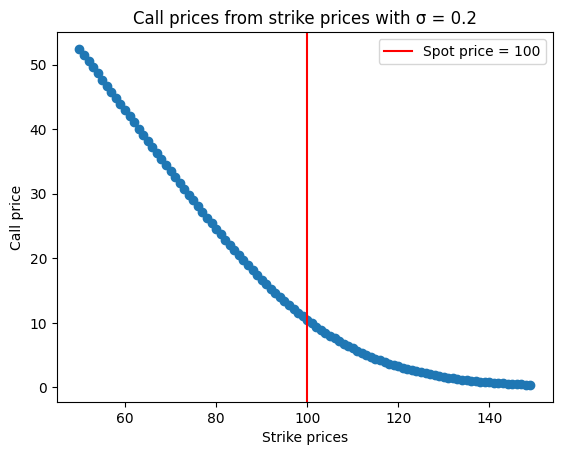

In [43]:
Ks = np.arange(50, 150, 1)
plt.scatter(Ks, call_price(S, Ks, T, r, sigma))
plt.xlabel("Strike prices")
plt.ylabel("Call price")
plt.axvline(S, color="red", label=f"Spot price = {S}")
plt.legend(loc="upper right")
plt.title(f"Call prices from strike prices with σ = {sigma}")
plt.show();

# The stock needs to expire above the strike price to be ITM, hence the call value decreasing as the strike price increases

# Monte Carlo

In [44]:
# Using the same assumptions as BS, simulate a random price at expiry based on some input noise 
def price_at_expiry(S, K, T, r, sigma, noise):
    return S * np.exp((r - sigma**2 / 2)*T + sigma * np.sqrt(T)*noise)

In [45]:
# Generate many many simulated prices at expiry 
expiry_prices = price_at_expiry(S, K, T, r, sigma, np.random.randn(10000000))

In [46]:
# Calculate the payouts
payouts = list(map(lambda x: np.maximum(x - K, 0), expiry_prices))

In [47]:
# One would expect the calculated price to be the same as the expected payout - not bad!!
np.mean(payouts) * np.exp(-r*T)

np.float64(10.450760180454342)